# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

df['date'] = pd.to_datetime(df['date'])

In [9]:
quarter_map = {
    12:'1', 1:'1',2:'1',
    3:'2',4:'2',5:'2',
    6:'3',7:'3',8:'3',9:'3',
    10:'4',11:'4'
}

df['weather_season_india'] = df['date'].dt.month.map(quarter_map)


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

Найбільша невизначеність 09.2012. Високе стандартне відхилення означає високі коливання і невизначеність.

In [10]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

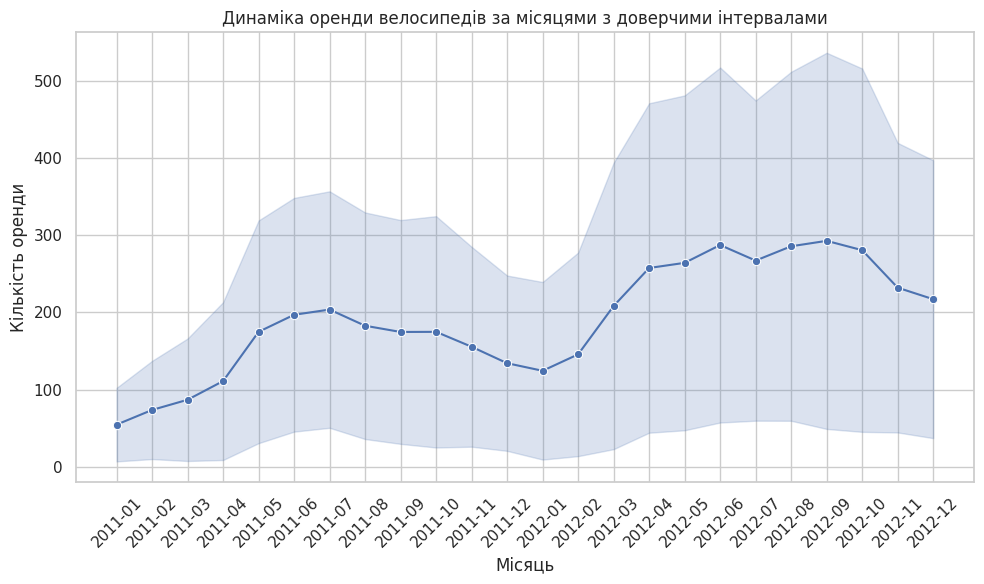

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data = df,
    x='month_year',
    y='count',
    estimator='mean',
    errorbar='sd',
    marker='o'
    )

plt.title('Динаміка оренди велосипедів за місяцями з доверчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45)
plt.tight_layout();

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

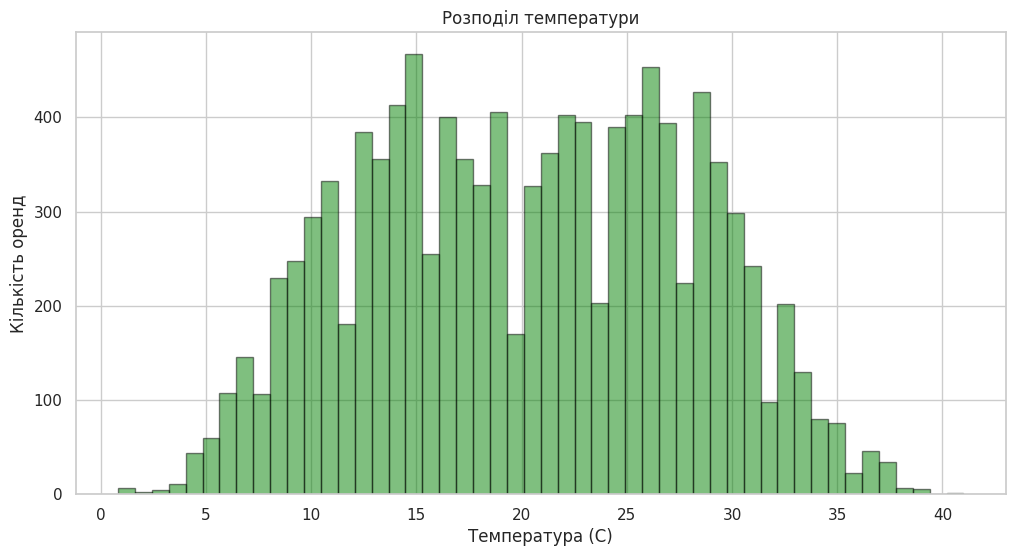

In [30]:
df['temp'].plot.hist(
    bins=50,
    figsize=(12,6),
    alpha=0.5,
    color="green",
    edgecolor='black',
    title='Розподіл температури',
    xlabel='Температура (С)',
    ylabel='Кількість оренд'
    );

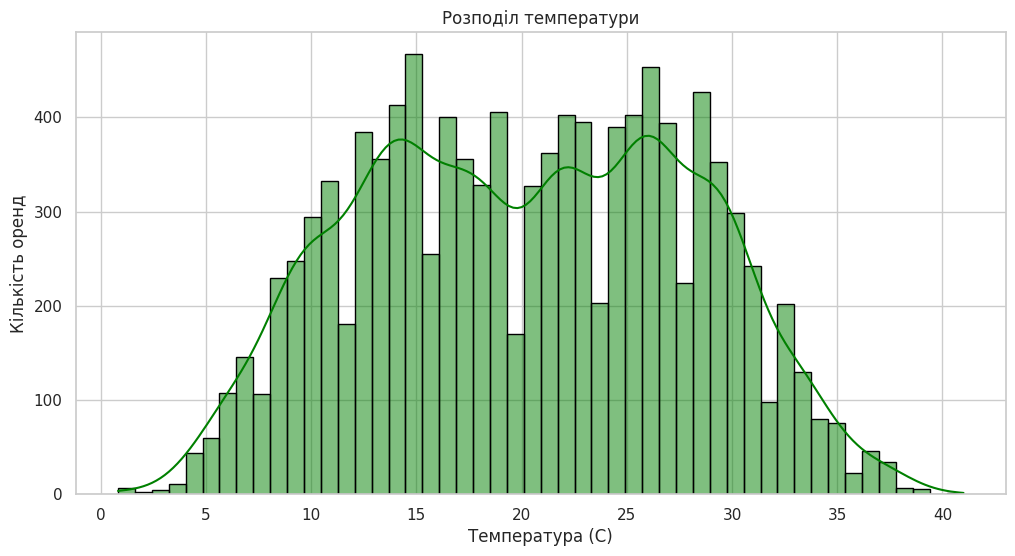

In [29]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='temp',
    bins=50,
    alpha=0.5 ,
    color="green",
    edgecolor='black',
    kde=True
)


plt.title('Розподіл температури')
plt.xlabel('Температура (С)')
plt.ylabel('Кількість оренд')
plt.show()


1. Я не бачу жодної різниця, або вона дуже мінімальна. Різниця глибше - seaborn має більше статистичних опцій, зручніший код та більше налаштувань.
2. З цією лініє - більш видно форму розподілу, вона ніби згладжує. Бачимо плавну криву.
Ця лінія називається KDE - ядерна оцінка щільності

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

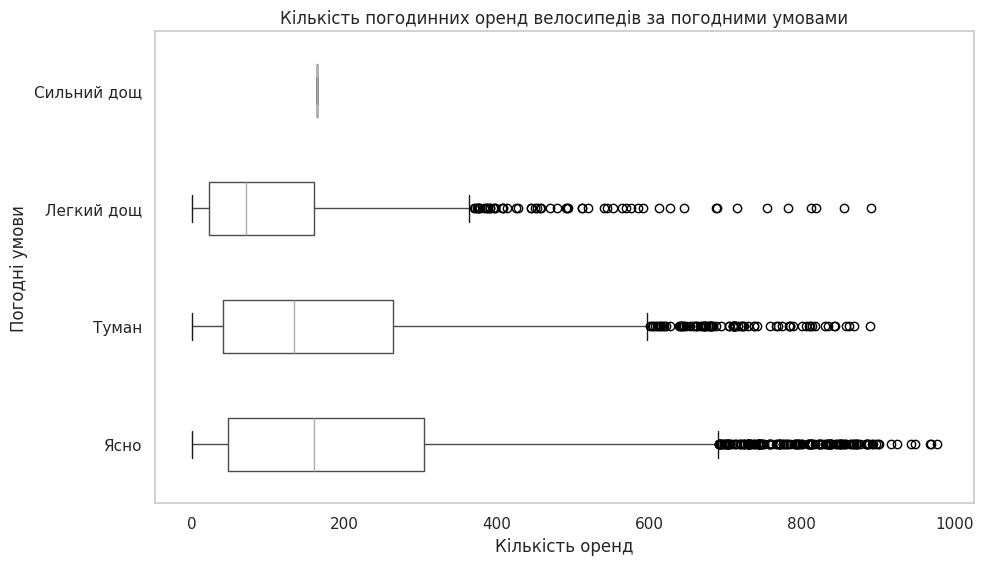

In [ ]:
df.boxplot(
    column = 'count',
    by='weather',
    figsize=(10,6),
    vert=False,
    grid=False
)

plt.title('Кількість погодинних оренд велосипедів за погодними умовами')
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')
plt.yticks([1,2,3,4],['Ясно','Туман','Легкий дощ','Сильний дощ'])
plt.suptitle('')
plt.tight_layout()
plt.show()

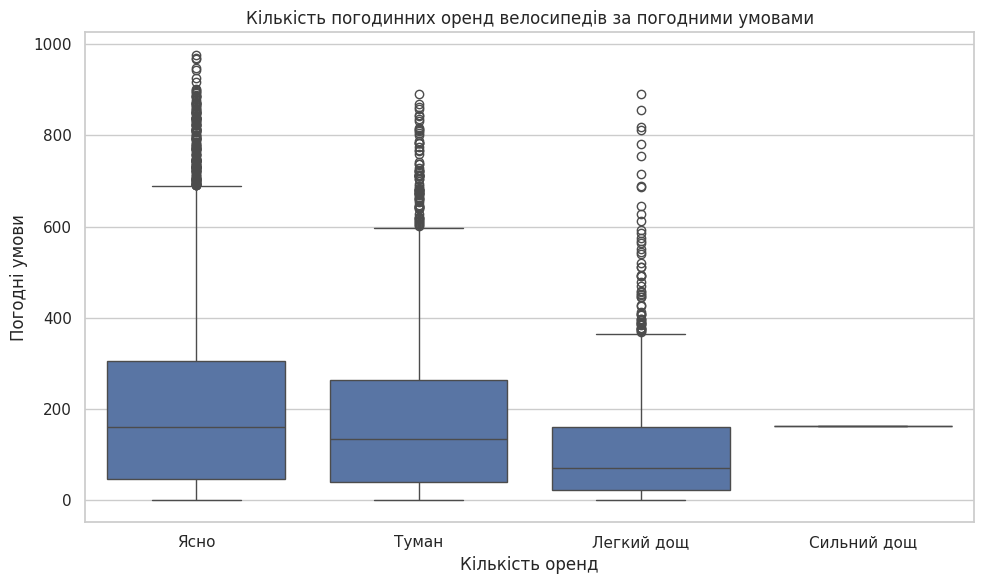

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data = df,
    x = 'weather',
    y = 'count'
)

plt.title('Кількість погодинних оренд велосипедів за погодними умовами')
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')
plt.xticks([0,1,2,3],['Ясно','Туман','Легкий дощ','Сильний дощ'])
plt.tight_layout()
plt.show()

Відмінність в тому, що відрізняється сітка, колір боксів плотів за стандартом та форма. З Seaborn - код виглядає простіше та зрозуміліше.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [23]:
correlation = df[['holiday','workingday','temp', 'atemp','casual','registered', 'count', 'humidity','windspeed','weather_season_india']].corr()
correlation

,holiday,workingday,temp,atemp,casual,registered,count,humidity,windspeed,weather_season_india
holiday,1.000000,-0.250491,0.000295,-0.005215,0.043799,-0.020956,-0.005393,0.001929,0.008409,0.045656
workingday,-0.250491,1.000000,0.029966,0.024660,-0.319111,0.119460,0.011594,-0.010880,0.013373,-0.004863
temp,0.000295,0.029966,1.000000,0.984948,0.467097,0.318571,0.394454,-0.064949,-0.017852,0.504309
atemp,-0.005215,0.024660,0.984948,1.000000,0.462067,0.314635,0.389784,-0.043536,-0.057473,0.498450
casual,0.043799,-0.319111,0.467097,0.462067,1.000000,0.497250,0.690414,-0.348187,0.092276,0.215580
registered,-0.020956,0.119460,0.318571,0.314635,0.497250,1.000000,0.970948,-0.265458,0.091052,0.169466
count,-0.005393,0.011594,0.394454,0.389784,0.690414,0.970948,1.000000,-0.317371,0.101369,0.200759
humidity,0.001929,-0.010880,-0.064949,-0.043536,-0.348187,-0.265458,-0.317371,1.000000,-0.318607,0.088649
windspeed,0.008409,0.013373,-0.017852,-0.057473,0.092276,0.091052,0.101369,-0.318607,1.000000,-0.074939
weather_season_india,0.045656,-0.004863,0.504309,0.498450,0.215580,0.169466,0.200759,0.088649,-0.074939,1.000000


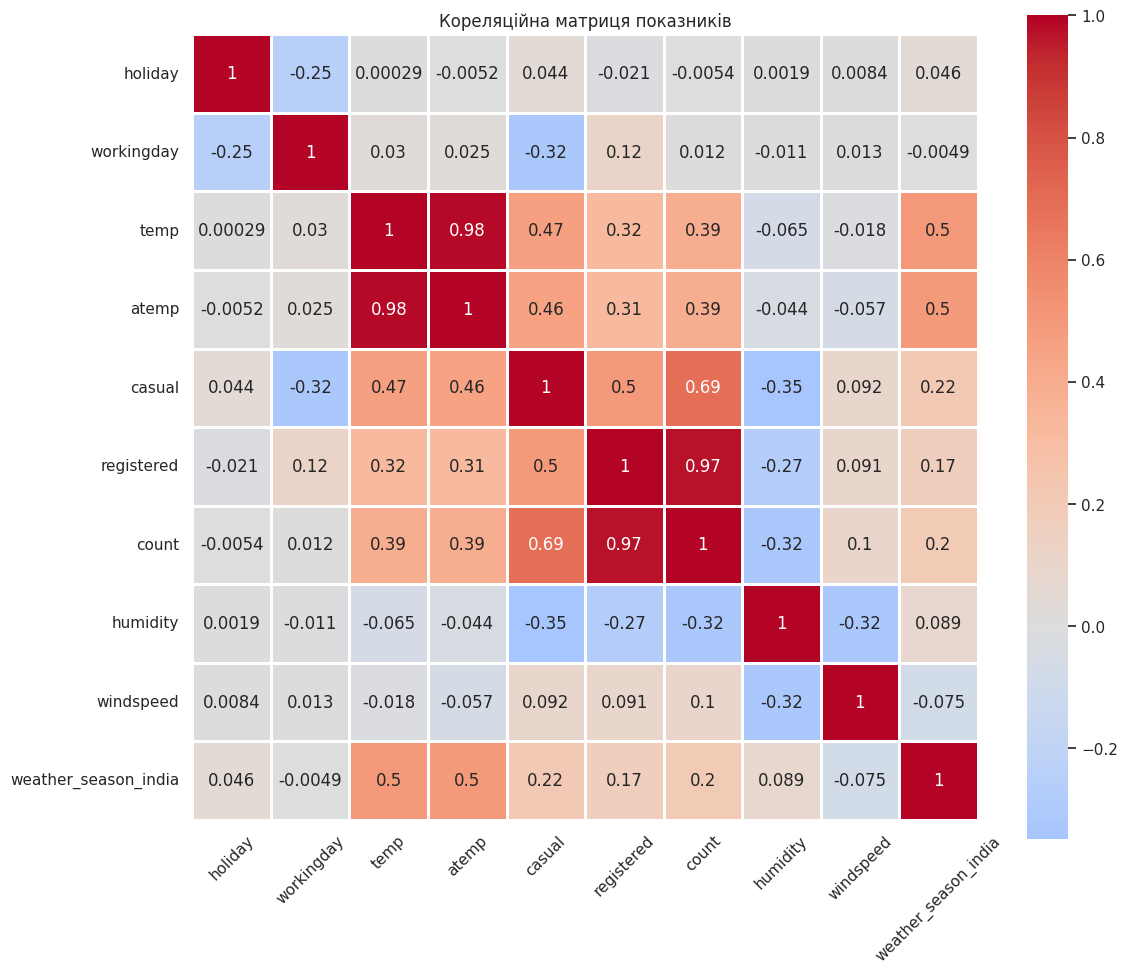

In [27]:
from matplotlib import colormaps
plt.figure(figsize=(12,10))

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1)


plt.xticks(rotation=45)
plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()



1. Найсильніша кореляція з кількістю оренд(count) спостерігається з кількість зареєстрованих користувачів(registred), кількість випадкових користувачів(casual) та температурою(temp).
2. Між температурою(temp) та як відчувається ця температура(atemp). Справа в тому, що те як відчувається температура обчислюється на основі реальної температури, тому ці зміни незалежні. На те як відчувається температура в спеку впливає вологість, вітер. Тому при зростанні температури - відчуття температури майже завжди зростає.
3. Негативну кореляцію мають - вологість/кількість оренд, кількість не зареєстрованих користовачів/вологість та вологість/швидкість вітру.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


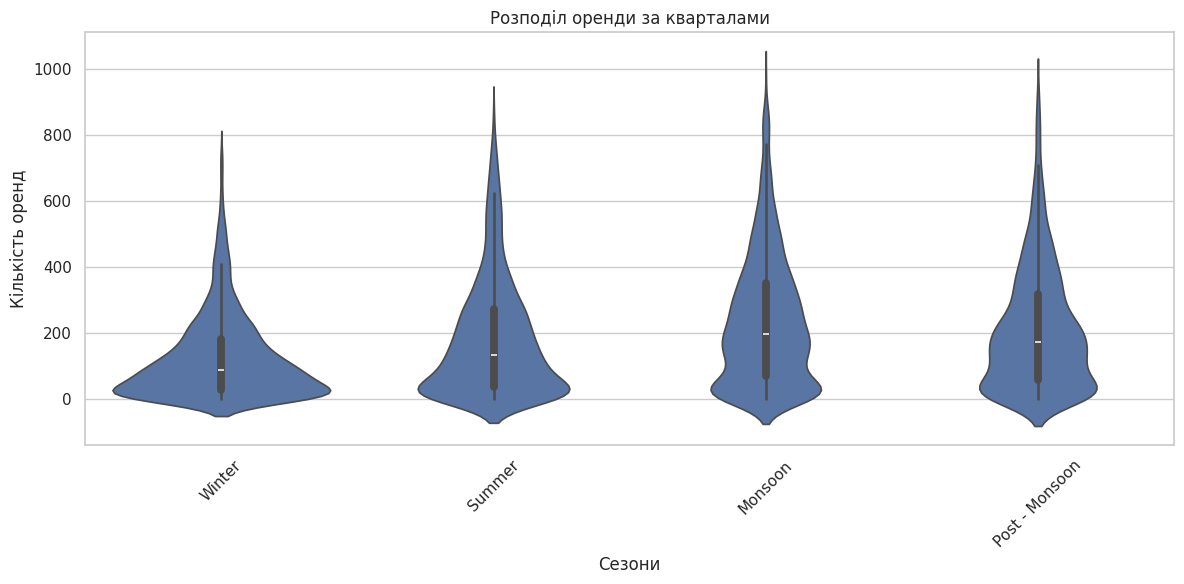

In [13]:
plt.figure(figsize=(12,6))

sns.violinplot(data=df, x='weather_season_india', y='count')

plt.xticks(rotation=45)
plt.xticks([0,1,2,3],["Winter", "Summer","Monsoon", "Post - Monsoon" ])
plt.title('Розподіл оренди за кварталами')
plt.ylabel('Кількість оренд')
plt.xlabel('Сезони')
plt.tight_layout()
plt.show()

1. Товщина скрипки показує - кількість значень. Чим більша товщина - тим більше в ній значень.
2. В 3 кварталі - Monsoon. Ми бачимо досить широкий розкид значень.
3. Хочеться відмітити, що це виглядає більш сучасно, ми одразу можемо побачити форму розподілу даних і квартилі одночасно. Також violin plot відображає мультимодальність.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

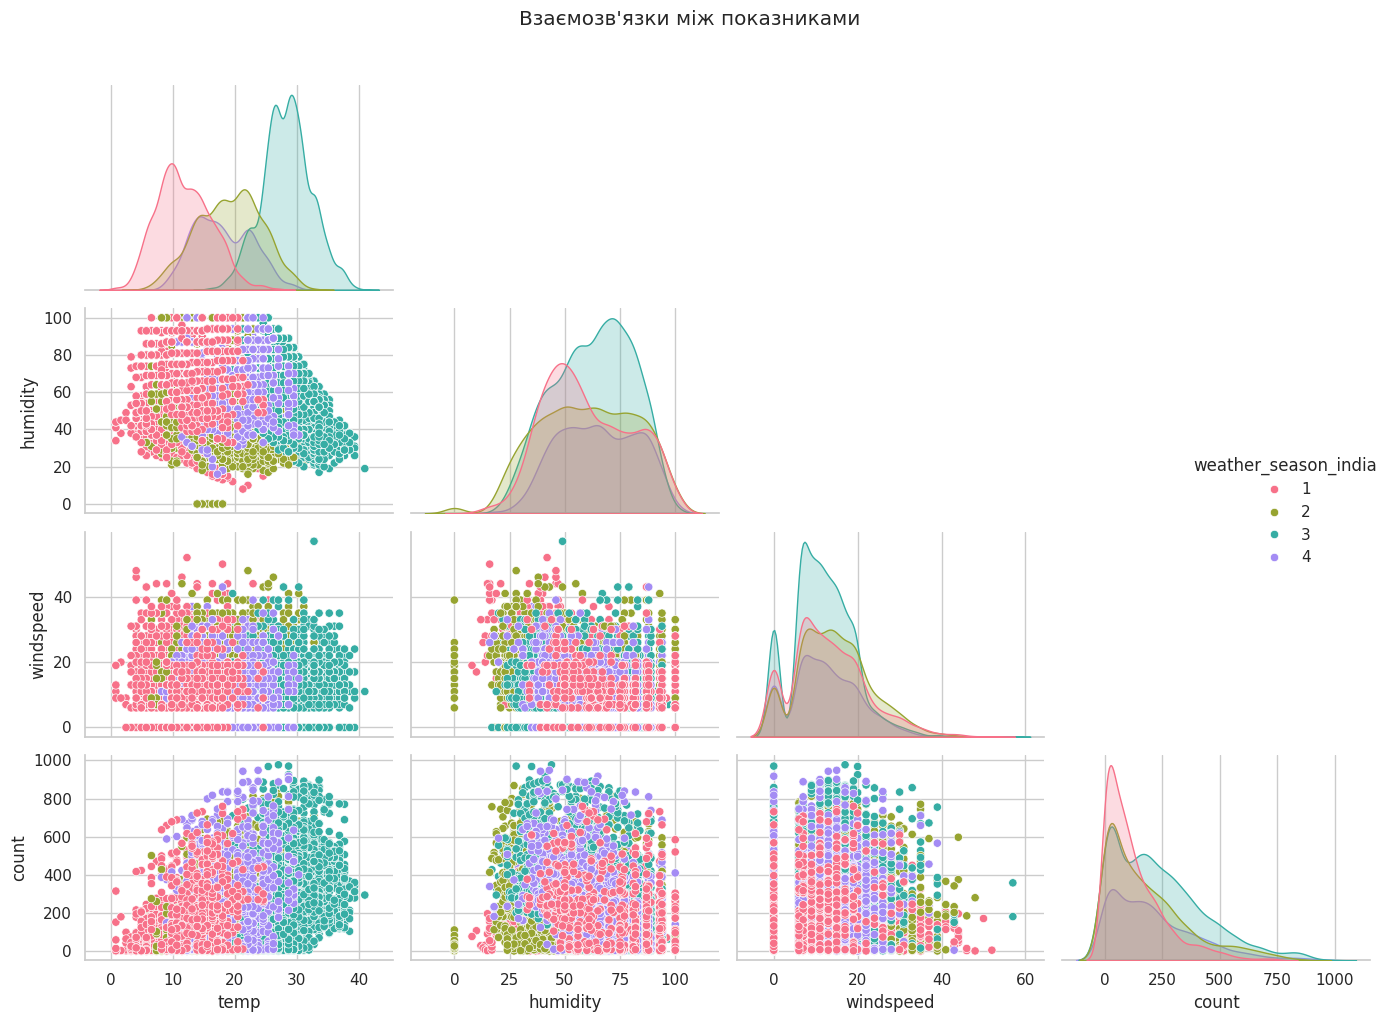

In [17]:
sns.pairplot(df,
             vars=['temp', 'humidity', 'windspeed','count'],
             hue='weather_season_india',
             palette='husl',
             diag_kind='kde',
             height=2.5,
             corner=True,
             aspect=1.2
      )


plt.suptitle('Взаємозв\'язки між показниками', y=1.02)
plt.tight_layout()
plt.show()

1. Найсильніший лінійний зв'язок спостерігається між кількістю оренд та температурою.
2. Найбільше між кварталами відрізняється температура.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

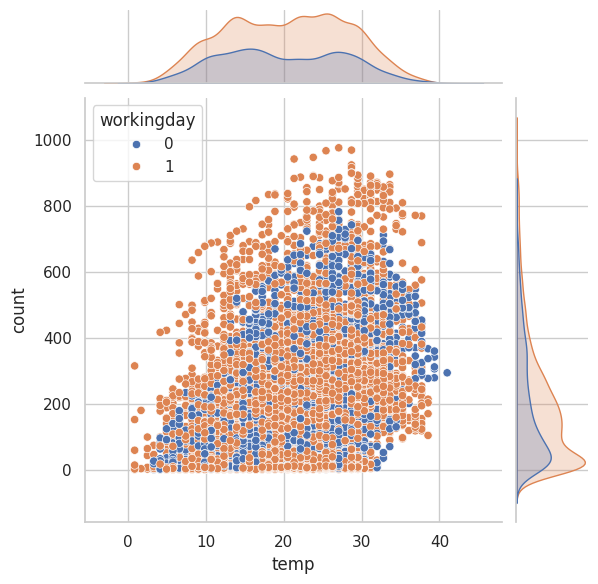

In [ ]:
sns.jointplot(data=df, x="temp", y="count", hue="workingday");

1. Графік згори показує розподіл температур, а графік праворуч - розподіл кількості оренд, кольорами відмічений взаємозв'язок з робочими та не робочими днями.
2. Так, різниця є. Кількість оренд в робочий день переважає. Ми вже бачили таку закономірність в одному з наших попередніх досліджень.
Наш корисистувач використовує оренду велосипедів для повсякденного життя, робота, школа, пересування в місті.

workingday - чи є день робочим (0=ні, 1=так)
